In [31]:
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

from torch_geometric.loader import DataLoader
from torch_geometric.nn import GATConv, global_mean_pool

In [32]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [33]:
graphs = torch.load(
    "worldcup_2022_graphs.pt",
    map_location="cpu",
    weights_only=False
)

print("Liczba grafów:", len(graphs))
print(graphs[0])

Liczba grafów: 165438
Data(x=[18, 9], edge_index=[2, 78], edge_attr=[78, 3], actor_mask=[18], event_features=[1, 8], y_pressure=[1], y_turnover=[1], event_id='05a57281-9295-408a-9c4f-e32d7fad4d96', match_id=3857276, event_index=5)


In [34]:
g = graphs[0]

print("x:", g.x.shape)
print("edge_index:", g.edge_index.shape)
print("edge_attr:", g.edge_attr.shape)
print("actor_mask:", g.actor_mask.shape)
print("event_features:", g.event_features.shape)
print("y_pressure:", g.y_pressure)
print("y_turnover:", g.y_turnover)
print("match_id:", g.match_id)

x: torch.Size([18, 9])
edge_index: torch.Size([2, 78])
edge_attr: torch.Size([78, 3])
actor_mask: torch.Size([18])
event_features: torch.Size([1, 8])
y_pressure: tensor([0.])
y_turnover: tensor([0.])
match_id: 3857276


In [35]:
pressure_values = [int(g.y_pressure.item()) for g in graphs]
turnover_values = [int(g.y_turnover.item()) for g in graphs]

print("Pressure:")
print(pd.Series(pressure_values).value_counts())
print(pd.Series(pressure_values).value_counts(normalize=True))

print("\nTurnover:")
print(pd.Series(turnover_values).value_counts())
print(pd.Series(turnover_values).value_counts(normalize=True))

Pressure:
0    141284
1     24154
Name: count, dtype: int64
0    0.854
1    0.146
Name: proportion, dtype: float64

Turnover:
0    155349
1     10089
Name: count, dtype: int64
0    0.939016
1    0.060984
Name: proportion, dtype: float64


In [36]:
unique_match_ids = np.array(sorted(set(int(g.match_id) for g in graphs)))

print("Liczba meczów:", len(unique_match_ids))

train_matches, temp_matches = train_test_split(
    unique_match_ids,
    test_size=0.30,
    random_state=SEED,
)

val_matches, test_matches = train_test_split(
    temp_matches,
    test_size=0.50,
    random_state=SEED,
)

train_matches = set(train_matches)
val_matches = set(val_matches)
test_matches = set(test_matches)

train_graphs = [g for g in graphs if int(g.match_id) in train_matches]
val_graphs = [g for g in graphs if int(g.match_id) in val_matches]
test_graphs = [g for g in graphs if int(g.match_id) in test_matches]

print("Train graphs:", len(train_graphs))
print("Val graphs:", len(val_graphs))
print("Test graphs:", len(test_graphs))

print("Train matches:", len(train_matches))
print("Val matches:", len(val_matches))
print("Test matches:", len(test_matches))

Liczba meczów: 64
Train graphs: 111643
Val graphs: 25152
Test graphs: 28643
Train matches: 44
Val matches: 10
Test matches: 10


In [37]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_graphs,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_loader = DataLoader(
    val_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

test_loader = DataLoader(
    test_graphs,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

In [38]:
class PressingTurnoverGAT(nn.Module):
    def __init__(
        self,
        node_dim: int,
        edge_dim: int,
        event_dim: int,
        hidden_dim: int = 64,
        dropout: float = 0.2,
    ):
        super().__init__()

        self.gat1 = GATConv(
            in_channels=node_dim,
            out_channels=hidden_dim,
            heads=4,
            concat=True,
            edge_dim=edge_dim,
            dropout=dropout,
        )

        self.gat2 = GATConv(
            in_channels=hidden_dim * 4,
            out_channels=hidden_dim,
            heads=1,
            concat=False,
            edge_dim=edge_dim,
            dropout=dropout,
        )

        self.event_mlp = nn.Sequential(
            nn.Linear(event_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        self.shared = nn.Sequential(
            nn.Linear(hidden_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )

        self.pressure_head = nn.Linear(hidden_dim, 1)
        self.turnover_head = nn.Linear(hidden_dim, 1)

    def forward(self, batch):
        h = self.gat1(
            batch.x,
            batch.edge_index,
            edge_attr=batch.edge_attr,
        )
        h = F.elu(h)

        h = self.gat2(
            h,
            batch.edge_index,
            edge_attr=batch.edge_attr,
        )
        h = F.elu(h)

        graph_emb = global_mean_pool(h, batch.batch)

        actor_emb = h[batch.actor_mask]

        event_emb = self.event_mlp(batch.event_features)

        combined = torch.cat(
            [graph_emb, actor_emb, event_emb],
            dim=-1,
        )

        z = self.shared(combined)

        pressure_logit = self.pressure_head(z).squeeze(-1)
        turnover_logit = self.turnover_head(z).squeeze(-1)

        return pressure_logit, turnover_logit

In [39]:
node_dim = train_graphs[0].x.shape[1]
edge_dim = train_graphs[0].edge_attr.shape[1]
event_dim = train_graphs[0].event_features.shape[1]

print("node_dim:", node_dim)
print("edge_dim:", edge_dim)
print("event_dim:", event_dim)

model = PressingTurnoverGAT(
    node_dim=node_dim,
    edge_dim=edge_dim,
    event_dim=event_dim,
    hidden_dim=64,
    dropout=0.2,
).to(device)

print(model)

node_dim: 9
edge_dim: 3
event_dim: 8
PressingTurnoverGAT(
  (gat1): GATConv(9, 64, heads=4)
  (gat2): GATConv(256, 64, heads=1)
  (event_mlp): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
  )
  (shared): Sequential(
    (0): Linear(in_features=192, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=64, bias=True)
    (4): ReLU()
  )
  (pressure_head): Linear(in_features=64, out_features=1, bias=True)
  (turnover_head): Linear(in_features=64, out_features=1, bias=True)
)


In [40]:
def compute_pos_weight(graphs, target_attr):
    y = torch.tensor([
        float(getattr(g, target_attr).item())
        for g in graphs
    ])

    num_pos = y.sum()
    num_neg = len(y) - num_pos

    pos_weight = num_neg / (num_pos + 1e-8)

    return pos_weight


pressure_pos_weight = compute_pos_weight(train_graphs, "y_pressure").to(device)
turnover_pos_weight = compute_pos_weight(train_graphs, "y_turnover").to(device)

print("pressure_pos_weight:", pressure_pos_weight.item())
print("turnover_pos_weight:", turnover_pos_weight.item())

pressure_pos_weight: 5.872453212738037
turnover_pos_weight: 15.556873321533203


In [41]:
pressure_criterion = nn.BCEWithLogitsLoss(
    pos_weight=pressure_pos_weight
)

turnover_criterion = nn.BCEWithLogitsLoss(
    pos_weight=turnover_pos_weight
)

In [42]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4,
)

In [43]:
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

In [44]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    pressure_criterion,
    turnover_criterion,
    device,
    pressure_weight=1.0,
    turnover_weight=1.0,
):
    model.train()

    total_loss = 0.0
    total_pressure_loss = 0.0
    total_turnover_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pressure_logits, turnover_logits = model(batch)

        y_pressure = batch.y_pressure.view(-1).float()
        y_turnover = batch.y_turnover.view(-1).float()

        pressure_loss = pressure_criterion(
            pressure_logits,
            y_pressure,
        )

        turnover_loss = turnover_criterion(
            turnover_logits,
            y_turnover,
        )

        loss = (
            pressure_weight * pressure_loss
            + turnover_weight * turnover_loss
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=5.0,
        )

        optimizer.step()

        n = batch.num_graphs

        total_loss += loss.item() * n
        total_pressure_loss += pressure_loss.item() * n
        total_turnover_loss += turnover_loss.item() * n

    return {
        "loss": total_loss / len(loader.dataset),
        "pressure_loss": total_pressure_loss / len(loader.dataset),
        "turnover_loss": total_turnover_loss / len(loader.dataset),
    }

In [45]:
@torch.no_grad()
def evaluate_loss(
    model,
    loader,
    pressure_criterion,
    turnover_criterion,
    device,
    pressure_weight=1.0,
    turnover_weight=1.0,
):
    model.eval()

    total_loss = 0.0
    total_pressure_loss = 0.0
    total_turnover_loss = 0.0

    for batch in loader:
        batch = batch.to(device)

        pressure_logits, turnover_logits = model(batch)

        y_pressure = batch.y_pressure.view(-1).float()
        y_turnover = batch.y_turnover.view(-1).float()

        pressure_loss = pressure_criterion(
            pressure_logits,
            y_pressure,
        )

        turnover_loss = turnover_criterion(
            turnover_logits,
            y_turnover,
        )

        loss = (
            pressure_weight * pressure_loss
            + turnover_weight * turnover_loss
        )

        n = batch.num_graphs

        total_loss += loss.item() * n
        total_pressure_loss += pressure_loss.item() * n
        total_turnover_loss += turnover_loss.item() * n

    return {
        "loss": total_loss / len(loader.dataset),
        "pressure_loss": total_pressure_loss / len(loader.dataset),
        "turnover_loss": total_turnover_loss / len(loader.dataset),
    }

In [46]:
@torch.no_grad()
def predict_all(model, loader, device):
    model.eval()

    y_pressure_all = []
    p_pressure_all = []

    y_turnover_all = []
    p_turnover_all = []

    for batch in loader:
        batch = batch.to(device)

        pressure_logits, turnover_logits = model(batch)

        p_pressure = torch.sigmoid(pressure_logits).detach().cpu().numpy()
        p_turnover = torch.sigmoid(turnover_logits).detach().cpu().numpy()

        y_pressure = batch.y_pressure.view(-1).detach().cpu().numpy()
        y_turnover = batch.y_turnover.view(-1).detach().cpu().numpy()

        y_pressure_all.extend(y_pressure)
        p_pressure_all.extend(p_pressure)

        y_turnover_all.extend(y_turnover)
        p_turnover_all.extend(p_turnover)

    return {
        "y_pressure": np.array(y_pressure_all),
        "p_pressure": np.array(p_pressure_all),
        "y_turnover": np.array(y_turnover_all),
        "p_turnover": np.array(p_turnover_all),
    }


def binary_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    out = {
        "positive_rate": float(y_true.mean()),
        "prob_mean": float(y_prob.mean()),
        "prob_std": float(y_prob.std()),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "confusion_matrix": confusion_matrix(y_true, y_pred),
    }

    if len(np.unique(y_true)) > 1:
        out["roc_auc"] = roc_auc_score(y_true, y_prob)
        out["pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out["roc_auc"] = np.nan
        out["pr_auc"] = np.nan

    return out


@torch.no_grad()
def evaluate_metrics(model, loader, device, threshold=0.5):
    preds = predict_all(model, loader, device)

    pressure_metrics = binary_metrics(
        preds["y_pressure"],
        preds["p_pressure"],
        threshold=threshold,
    )

    turnover_metrics = binary_metrics(
        preds["y_turnover"],
        preds["p_turnover"],
        threshold=threshold,
    )

    return {
        "pressure": pressure_metrics,
        "turnover": turnover_metrics,
    }

In [47]:
EPOCHS = 300

history = []

best_val_loss = float("inf")
best_model_path = "best_gat_model.pt"

patience = 12
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        pressure_criterion=pressure_criterion,
        turnover_criterion=turnover_criterion,
        device=device,
        pressure_weight=1.0,
        turnover_weight=1.0,
    )

    val_metrics = evaluate_loss(
        model=model,
        loader=val_loader,
        pressure_criterion=pressure_criterion,
        turnover_criterion=turnover_criterion,
        device=device,
        pressure_weight=1.0,
        turnover_weight=1.0,
    )

    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_pressure_loss": train_metrics["pressure_loss"],
        "train_turnover_loss": train_metrics["turnover_loss"],
        "val_loss": val_metrics["loss"],
        "val_pressure_loss": val_metrics["pressure_loss"],
        "val_turnover_loss": val_metrics["turnover_loss"],
        "lr": optimizer.param_groups[0]["lr"],
    }

    history.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        epochs_without_improvement = 0

        torch.save(
            model.state_dict(),
            best_model_path,
        )
    else:
        epochs_without_improvement += 1

    if epoch % 1 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"train={train_metrics['loss']:.4f} | "
            f"val={val_metrics['loss']:.4f} | "
            f"p_train={train_metrics['pressure_loss']:.4f} | "
            f"p_val={val_metrics['pressure_loss']:.4f} | "
            f"t_train={train_metrics['turnover_loss']:.4f} | "
            f"t_val={val_metrics['turnover_loss']:.4f} | "
            f"lr={optimizer.param_groups[0]['lr']:.6f}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch}")
        break


history_df = pd.DataFrame(history)
history_df.head()

Epoch 001 | train=2.0885 | val=1.9493 | p_train=0.9201 | p_val=0.8113 | t_train=1.1684 | t_val=1.1381 | lr=0.001000
Epoch 002 | train=1.9281 | val=1.9496 | p_train=0.8006 | p_val=0.8172 | t_train=1.1275 | t_val=1.1324 | lr=0.001000
Epoch 003 | train=1.8665 | val=1.8353 | p_train=0.7487 | p_val=0.7109 | t_train=1.1177 | t_val=1.1244 | lr=0.001000
Epoch 004 | train=1.8334 | val=1.8127 | p_train=0.7202 | p_val=0.6907 | t_train=1.1132 | t_val=1.1220 | lr=0.001000
Epoch 005 | train=1.8077 | val=1.8310 | p_train=0.6992 | p_val=0.7175 | t_train=1.1085 | t_val=1.1135 | lr=0.001000
Epoch 006 | train=1.7958 | val=1.8083 | p_train=0.6907 | p_val=0.6899 | t_train=1.1052 | t_val=1.1184 | lr=0.001000
Epoch 007 | train=1.7934 | val=1.7912 | p_train=0.6903 | p_val=0.6678 | t_train=1.1031 | t_val=1.1234 | lr=0.001000
Epoch 008 | train=1.7829 | val=1.7840 | p_train=0.6825 | p_val=0.6706 | t_train=1.1004 | t_val=1.1134 | lr=0.001000
Epoch 009 | train=1.7750 | val=1.7722 | p_train=0.6769 | p_val=0.6640 | 

,epoch,train_loss,train_pressure_loss,train_turnover_loss,val_loss,val_pressure_loss,val_turnover_loss,lr
0,1,2.088507,0.920145,1.168362,1.949327,0.811272,1.138055,0.001
1,2,1.928112,0.800625,1.127486,1.949602,0.817195,1.132407,0.001
2,3,1.866451,0.748720,1.117731,1.835317,0.710924,1.124393,0.001
3,4,1.833362,0.720159,1.113203,1.812722,0.690738,1.121985,0.001
4,5,1.807672,0.699167,1.108506,1.831033,0.717499,1.113535,0.001


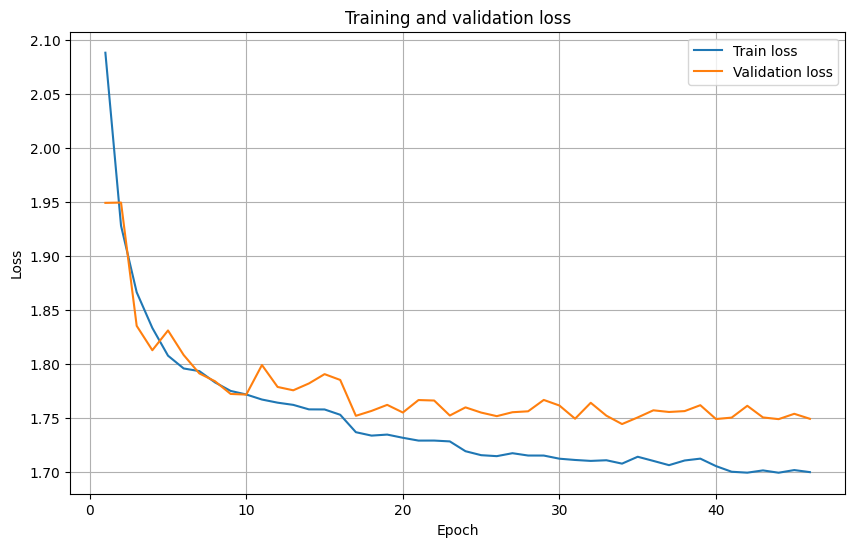

In [48]:
plt.figure(figsize=(10, 6))

plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(True)
plt.show()

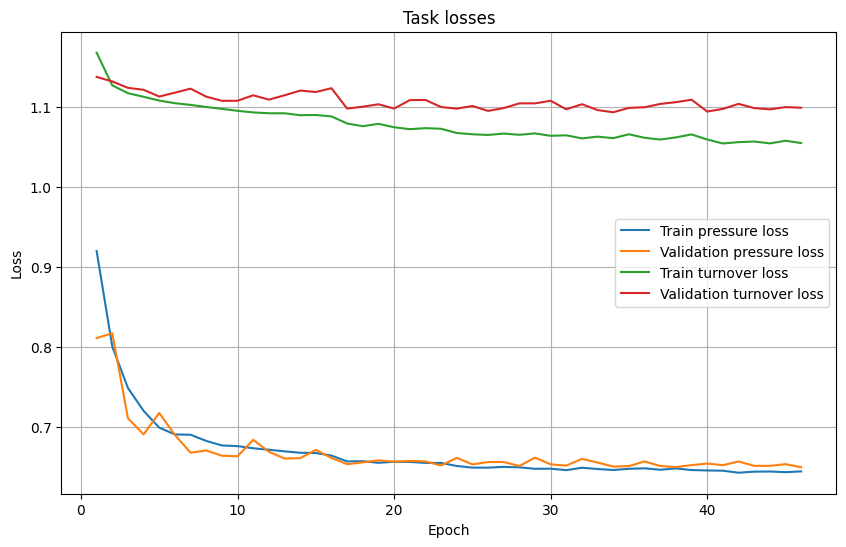

In [49]:
plt.figure(figsize=(10, 6))

plt.plot(
    history_df["epoch"],
    history_df["train_pressure_loss"],
    label="Train pressure loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_pressure_loss"],
    label="Validation pressure loss",
)

plt.plot(
    history_df["epoch"],
    history_df["train_turnover_loss"],
    label="Train turnover loss",
)

plt.plot(
    history_df["epoch"],
    history_df["val_turnover_loss"],
    label="Validation turnover loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Task losses")
plt.legend()
plt.grid(True)
plt.show()

In [50]:
model.load_state_dict(
    torch.load(best_model_path, map_location=device)
)

model = model.to(device)
model.eval()

print("Loaded best model from:", best_model_path)
print("Best val loss:", best_val_loss)

Loaded best model from: best_gat_model.pt
Best val loss: 1.744286084599774


In [51]:
test_loss = evaluate_loss(
    model=model,
    loader=test_loader,
    pressure_criterion=pressure_criterion,
    turnover_criterion=turnover_criterion,
    device=device,
)

test_eval = evaluate_metrics(
    model=model,
    loader=test_loader,
    device=device,
    threshold=0.5,
)

print("TEST LOSS")
print(test_loss)

print("\nTEST PRESSURE")
for k, v in test_eval["pressure"].items():
    print(k, v)

print("\nTEST TURNOVER")
for k, v in test_eval["turnover"].items():
    print(k, v)

TEST LOSS
{'loss': 1.6969591220722133, 'pressure_loss': 0.6204130681134659, 'turnover_loss': 1.0765460572279195}

TEST PRESSURE
positive_rate 0.14457284502321685
prob_mean 0.3212091326713562
prob_std 0.3193533718585968
accuracy 0.7949586286352687
precision 0.40595134665508253
recall 0.9026805119536344
f1 0.5600419507079182
confusion_matrix [[19032  5470]
 [  403  3738]]
roc_auc 0.9152431479751856
pr_auc 0.6544717768790973

TEST TURNOVER
positive_rate 0.06158572775198129
prob_mean 0.40353214740753174
prob_std 0.21972057223320007
accuracy 0.679817058269036
precision 0.12767668643812205
recall 0.719954648526077
f1 0.2168901033216634
confusion_matrix [[18202  8677]
 [  494  1270]]
roc_auc 0.7743100873917284
pr_auc 0.23584459278050277


In [52]:
results_df = pd.DataFrame([
    {
        "task": "pressure",
        "positive_rate": test_eval["pressure"]["positive_rate"],
        "prob_mean": test_eval["pressure"]["prob_mean"],
        "prob_std": test_eval["pressure"]["prob_std"],
        "accuracy": test_eval["pressure"]["accuracy"],
        "precision": test_eval["pressure"]["precision"],
        "recall": test_eval["pressure"]["recall"],
        "f1": test_eval["pressure"]["f1"],
        "roc_auc": test_eval["pressure"]["roc_auc"],
        "pr_auc": test_eval["pressure"]["pr_auc"],
    },
    {
        "task": "turnover",
        "positive_rate": test_eval["turnover"]["positive_rate"],
        "prob_mean": test_eval["turnover"]["prob_mean"],
        "prob_std": test_eval["turnover"]["prob_std"],
        "accuracy": test_eval["turnover"]["accuracy"],
        "precision": test_eval["turnover"]["precision"],
        "recall": test_eval["turnover"]["recall"],
        "f1": test_eval["turnover"]["f1"],
        "roc_auc": test_eval["turnover"]["roc_auc"],
        "pr_auc": test_eval["turnover"]["pr_auc"],
    },
])

results_df

,task,positive_rate,prob_mean,prob_std,accuracy,precision,recall,f1,roc_auc,pr_auc
0,pressure,0.144573,0.321209,0.319353,0.794959,0.405951,0.902681,0.560042,0.915243,0.654472
1,turnover,0.061586,0.403532,0.219721,0.679817,0.127677,0.719955,0.216890,0.774310,0.235845


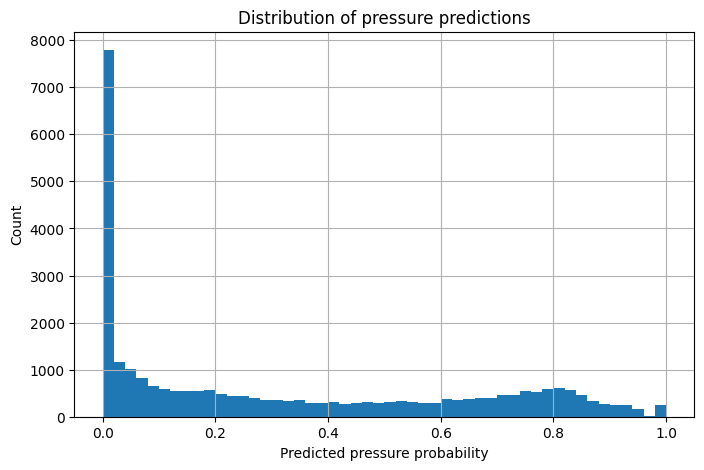

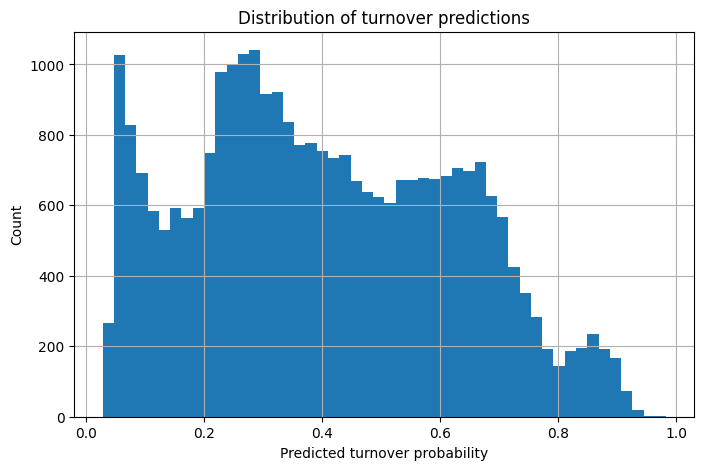

In [53]:
preds = predict_all(model, test_loader, device)

plt.figure(figsize=(8, 5))
plt.hist(preds["p_pressure"], bins=50)
plt.xlabel("Predicted pressure probability")
plt.ylabel("Count")
plt.title("Distribution of pressure predictions")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(preds["p_turnover"], bins=50)
plt.xlabel("Predicted turnover probability")
plt.ylabel("Count")
plt.title("Distribution of turnover predictions")
plt.grid(True)
plt.show()

In [54]:
history_df.to_csv("training_history.csv", index=False)
results_df.to_csv("test_results.csv", index=False)

torch.save(model.state_dict(), "final_gat_model.pt")